<a href="https://colab.research.google.com/github/roboy88/Mike-mentzer-bodybuilding-4-day-split-routine-data-analysis/blob/main/Mike_mentzer_bodybuilding_4_day_split_routine_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Exercise1.xlsx to Exercise1.xlsx
Saving Exercise2.xlsx to Exercise2.xlsx
Saving Exercise3.xlsx to Exercise3.xlsx
Saving Exercise4.xlsx to Exercise4.xlsx
Summary Statistics by Program:
         SumSkinfolds_mm  Systolic_BP
program                              
Mentzer        68.106306    67.341441
Other          68.106306    67.341441


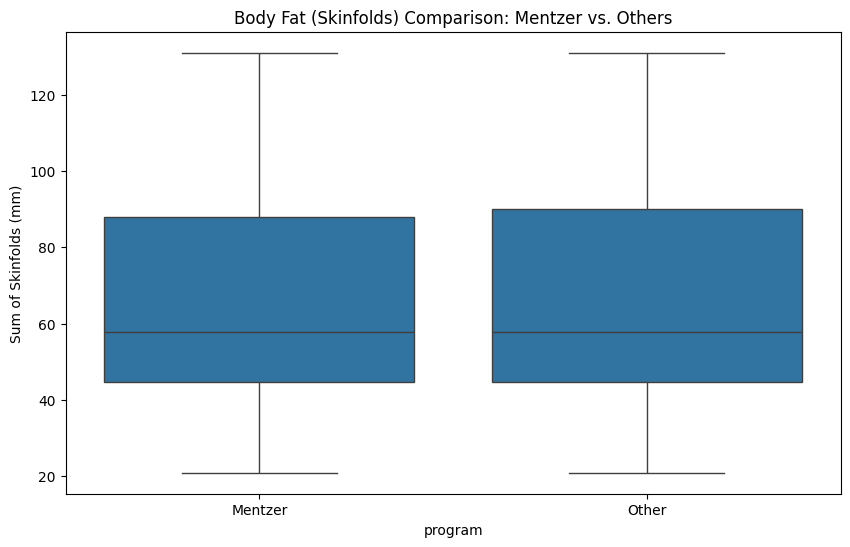

R² Score: 0.09987543572589053


In [3]:


# Step 1: Upload Excel files manually
from google.colab import files
uploaded = files.upload()
files = list(uploaded.keys())

# Step 2: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Step 3: Load and clean all Excel sheets
all_data = {}

for file in files:
    xls = pd.ExcelFile(file)
    for sheet_name in xls.sheet_names:
        df = xls.parse(sheet_name, skiprows=2)
        df.columns = [f"col_{i}" for i in range(len(df.columns))]
        df["source"] = f"{file}_{sheet_name}"
        all_data[f"{file}_{sheet_name}"] = df

# Step 4: Combine all data
df = pd.concat(all_data.values(), ignore_index=True)

# Step 5: Rename columns (adjust as needed based on your dataset)
df = df.rename(columns={
    "col_0": "ID",
    "col_1": "SumSkinfolds_mm",
    "col_2": "Systolic_BP"
})

# Step 6: Add program label based on source filename
df['program'] = df['source'].apply(lambda x: "Mentzer" if "Exercise1" in x else "Other")

# Step 7: Show summary statistics
print("Summary Statistics by Program:")
print(df.groupby("program")[["SumSkinfolds_mm", "Systolic_BP"]].mean())

# Step 8: Visualization
plt.figure(figsize=(10, 6))
sns.boxplot(x="program", y="SumSkinfolds_mm", data=df)
plt.title("Body Fat (Skinfolds) Comparison: Mentzer vs. Others")
plt.ylabel("Sum of Skinfolds (mm)")
plt.show()

# Step 9: Optional Linear Regression Model
df_model = df.dropna(subset=["SumSkinfolds_mm", "Systolic_BP"])
X = df_model[["Systolic_BP"]]
y = df_model["SumSkinfolds_mm"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("R² Score:", model.score(X_test, y_test))
